Loan Default Probability & Expected Loss Model
================================================

DATASET: 10,000 loans with features:
    credit_lines_outstanding  - number of open credit lines
    loan_amt_outstanding      — current outstanding loan balance ($)
    total_debt_outstanding    — total debt across all obligations ($)
    income                    — annual income ($)
    years_employed            — years at current employer
    fico_score                — FICO credit score (300–850)
    default                   — 1 if previously defaulted, 0 if not

GOAL:
    1. Predict PD (Probability of Default) for any new borrower
    2. Compute Expected Loss = PD × LGD × EAD
       where LGD (Loss Given Default) = 1 - Recovery Rate = 1 - 0.10 = 0.90
             EAD (Exposure at Default) = loan_amt_outstanding



In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, brier_score_loss, log_loss
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [13]:
# ══════════════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════════════

DATA_PATH     = '../data/cx_loan_data.csv'
RECOVERY_RATE = 0.10
LGD           = 1 - RECOVERY_RATE   # Loss Given Default = 0.90
RANDOM_STATE  = 42

In [14]:
# ══════════════════════════════════════════════════════════════════
# LOAD AND EXPLORE DATA
# ══════════════════════════════════════════════════════════════════

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


def explore_data(df: pd.DataFrame):
    print("=" * 65)
    print("  DATA OVERVIEW")
    print("=" * 65)
    print(f"  Rows: {len(df):,}   |   Columns: {df.shape[1]}")
    print(f"  Default rate: {df['default'].mean()*100:.1f}%  "
          f"({df['default'].sum():,} defaults out of {len(df):,})")
    print()
    print(df.describe().round(2).to_string())

    # Default rates by key segments
    print("\n  Default rate by credit_lines_outstanding:")
    print(df.groupby('credit_lines_outstanding')['default']
          .agg(['mean','count']).rename(columns={'mean':'default_rate','count':'n'})
          .assign(default_rate=lambda x: x['default_rate'].map('{:.1%}'.format))
          .to_string())

In [15]:
df = load_data(DATA_PATH)
explore_data(df)

  DATA OVERVIEW
  Rows: 10,000   |   Columns: 8
  Default rate: 18.5%  (1,851 defaults out of 10,000)

       customer_id  credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding     income  years_employed  fico_score   default
count     10000.00                  10000.00              10000.00                10000.00   10000.00        10000.00    10000.00  10000.00
mean    4974577.00                      1.46               4159.68                 8718.92   70039.90            4.55      637.56      0.19
std     2293889.71                      1.74               1421.40                 6627.16   20072.21            1.57       60.66      0.39
min     1000324.00                      0.00                 46.78                   31.65    1000.00            0.00      408.00      0.00
25%     2977661.00                      0.00               3154.24                 4199.84   56539.87            3.00      597.00      0.00
50%     4989501.50                      1.00             

In [16]:
# ══════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create economically meaningful features that capture credit risk:

    debt_to_income     : total debt burden relative to income
                         → higher = more stressed borrower
    loan_to_income     : specific loan size relative to earnings
                         → higher = harder to service this loan
    debt_service_ratio : total_debt / loan_amt (leverage concentration)
    fico_band          : bin FICO into 5 risk tiers (regulatory standard)
    low_fico_flag      : binary flag for subprime scores (<600)
    high_credit_lines  : flag for 5+ open credit lines (credit-hungry)
    """
    df = df.copy()

    df['debt_to_income']     = df['total_debt_outstanding'] / (df['income'] + 1)
    df['loan_to_income']     = df['loan_amt_outstanding']   / (df['income'] + 1)
    df['debt_service_ratio'] = df['total_debt_outstanding'] / (df['loan_amt_outstanding'] + 1)
    df['low_fico_flag']      = (df['fico_score'] < 600).astype(int)
    df['high_credit_lines']  = (df['credit_lines_outstanding'] >= 5).astype(int)

    return df


FEATURE_COLS = [
    'credit_lines_outstanding',
    'loan_amt_outstanding',
    'total_debt_outstanding',
    'income',
    'years_employed',
    'fico_score',
    'debt_to_income',
    'loan_to_income',
    'debt_service_ratio',
    'low_fico_flag',
    'high_credit_lines',
]


In [17]:
engineer_features(df)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,debt_to_income,loan_to_income,debt_service_ratio,low_fico_flag,high_credit_lines
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050172,0.066908,0.749725,0,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308778,0.073507,4.198496,1,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030786,0.051057,0.602802,0,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033644,0.064104,0.524731,0,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075432,0.057393,1.313328,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0,0.059817,0.071058,0.841526,0,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0,0.068252,0.051847,1.316096,0,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0,0.126018,0.080857,1.558026,1,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0,0.020481,0.064576,0.317061,0,0


In [18]:
# ══════════════════════════════════════════════════════════════════
# TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════════

def prepare_data(df: pd.DataFrame):
    df = engineer_features(df)
    X  = df[FEATURE_COLS]
    y  = df['default']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )

    # Scale features for logistic regression
    scaler  = StandardScaler()
    Xs_train = scaler.fit_transform(X_train)
    Xs_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, Xs_train, Xs_test, scaler


In [19]:
prepare_data(df)

(      credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
 9005                         5           5183.888841            25675.783830   
 8868                         1           2831.062536             7667.151577   
 5117                         4           5801.851720            18399.303860   
 3187                         1           2313.910680             5858.196071   
 4257                         0           6064.400513             1144.970524   
 ...                        ...                   ...                     ...   
 840                          5           2743.573107            22578.373430   
 8454                         1           4528.393585             8666.414234   
 2218                         0           1237.522722             1821.572240   
 4174                         0           3537.898842             2447.192640   
 3463                         0           4702.507740              753.649231   
 
             income  years

In [20]:
# ══════════════════════════════════════════════════════════════════
# TRAIN THREE MODELS
# ══════════════════════════════════════════════════════════════════

def train_models(X_train, y_train, Xs_train, Xs_test, X_test, y_test):
    """
    Three models, each with a different philosophy:

    1. Logistic Regression — interpretable, linear decision boundary,
       industry standard for credit scoring (Basel-compliant, auditable)

    2. Random Forest — ensemble of decision trees, captures nonlinear
       interactions (e.g. high debt_to_income AND low FICO = very risky),
       robust to outliers

    3. Gradient Boosting — sequential trees that correct prior errors,
       typically highest accuracy, used in production risk engines
    """
    models = {}

    # ── Logistic Regression ───────────────────────────────────────
    lr = LogisticRegression(
        C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
    )
    lr.fit(Xs_train, y_train)
    models['Logistic Regression'] = {
        'model': lr,
        'predict_proba': lambda X: lr.predict_proba(X)[:, 1],
        'needs_scaling': True,
    }

    # ── Random Forest ─────────────────────────────────────────────
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    models['Random Forest'] = {
        'model': rf,
        'predict_proba': lambda X: rf.predict_proba(X)[:, 1],
        'needs_scaling': False,
    }

    # ── Gradient Boosting ─────────────────────────────────────────
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    )
    gb.fit(X_train, y_train)
    models['Gradient Boosting'] = {
        'model': gb,
        'predict_proba': lambda X: gb.predict_proba(X)[:, 1],
        'needs_scaling': False,
    }

    return models

In [21]:
# ══════════════════════════════════════════════════════════════════
# EVALUATE ALL MODELS
# ══════════════════════════════════════════════════════════════════

def evaluate_models(models, X_test, y_test, Xs_test):
    """
    Metrics used:

    ROC-AUC  : area under receiver-operating curve — gold standard for
               ranking/discrimination. 0.5 = random, 1.0 = perfect.
               Target for credit risk: >0.75 is good, >0.85 is excellent.

    Brier Score : mean squared error of probability estimates.
                  Lower = better calibrated probabilities.

    Log-Loss : penalises confident wrong predictions heavily.

    Gini = 2×AUC - 1 : common in UK/EU banking regulation.
    """
    print("\n" + "=" * 65)
    print("  MODEL COMPARISON")
    print("=" * 65)
    print(f"  {'Model':<25} {'ROC-AUC':>9} {'Gini':>9} {'Brier':>9} {'LogLoss':>9}")
    print(f"  {'-'*24} {'-'*9} {'-'*9} {'-'*9} {'-'*9}")

    results = {}
    for name, info in models.items():
        X_eval = Xs_test if info['needs_scaling'] else X_test
        probs  = info['predict_proba'](X_eval)
        auc    = roc_auc_score(y_test, probs)
        brier  = brier_score_loss(y_test, probs)
        ll     = log_loss(y_test, probs)
        gini   = 2 * auc - 1
        results[name] = {'auc': auc, 'gini': gini, 'brier': brier,
                          'logloss': ll, 'probs': probs}
        print(f"  {name:<25} {auc:>9.4f} {gini:>9.4f} {brier:>9.4f} {ll:>9.4f}")

    best = max(results, key=lambda k: results[k]['auc'])
    print(f"\n  Best model by ROC-AUC: {best}")
    return results, best

In [22]:
# ══════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════

def print_feature_importance(models, scaler):
    print("\n" + "=" * 65)
    print("  FEATURE IMPORTANCE / COEFFICIENTS")
    print("=" * 65)

    # Logistic Regression coefficients (after scaling → comparable)
    lr     = models['Logistic Regression']['model']
    coeffs = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values(key=abs, ascending=False)
    print("\n  Logistic Regression — standardised coefficients (|coef|↑ = more impact):")
    for feat, coef in coeffs.items():
        bar = '█' * int(abs(coef) * 10)
        sign = '+' if coef > 0 else '-'
        print(f"    {feat:<28} {sign}{abs(coef):.4f}  {bar}")

    # Random Forest feature importances
    rf    = models['Random Forest']['model']
    fi_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    print("\n  Random Forest — feature importances (Gini impurity reduction):")
    for feat, imp in fi_rf.items():
        bar = '█' * int(imp * 200)
        print(f"    {feat:<28}  {imp:.4f}  {bar}")

In [23]:
# ══════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════

def plot_results(models, results, X_test, y_test, Xs_test, df):
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle('Loan Default Probability Model — Analysis Report',
                 fontsize=15, fontweight='bold')

    colours = {'Logistic Regression': '#1f77b4',
               'Random Forest':       '#2ca02c',
               'Gradient Boosting':   '#d62728'}

    # ── Panel 1: ROC Curves ───────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot([0,1],[0,1],'k--',alpha=0.4,label='Random (AUC=0.50)')
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        ax1.plot(fpr, tpr, color=colours[name], lw=2,
                 label=f"{name} ({res['auc']:.3f})")
    ax1.set_title('ROC Curves', fontweight='bold')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3)

    # ── Panel 2: Default rate vs FICO ────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    fico_bins = pd.cut(df['fico_score'], bins=[300,550,600,650,700,750,850],
                       labels=['<550','550-600','600-650','650-700','700-750','>750'])
    dr_fico = df.groupby(fico_bins)['default'].mean() * 100
    ax2.bar(range(len(dr_fico)), dr_fico.values,
            color=['#d62728','#ff7f0e','#ffbb78','#98df8a','#2ca02c','#1f77b4'],
            edgecolor='black', alpha=0.85)
    ax2.set_xticks(range(len(dr_fico)))
    ax2.set_xticklabels(dr_fico.index, rotation=30, fontsize=8)
    ax2.set_title('Default Rate by FICO Score Band', fontweight='bold')
    ax2.set_ylabel('Default Rate (%)')
    ax2.grid(alpha=0.3, axis='y')

    # ── Panel 3: Default rate vs Debt-to-Income ──────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    df2 = df.copy()
    df2['dti'] = df2['total_debt_outstanding'] / (df2['income'] + 1)
    dti_bins = pd.qcut(df2['dti'], q=5, labels=['Q1\n(Low)','Q2','Q3','Q4','Q5\n(High)'])
    dr_dti = df2.groupby(dti_bins)['default'].mean() * 100
    ax3.bar(range(5), dr_dti.values,
            color=['#1f77b4','#aec7e8','#ffbb78','#ff7f0e','#d62728'],
            edgecolor='black', alpha=0.85)
    ax3.set_xticks(range(5))
    ax3.set_xticklabels(dr_dti.index, fontsize=8)
    ax3.set_title('Default Rate by Debt-to-Income Quintile', fontweight='bold')
    ax3.set_ylabel('Default Rate (%)')
    ax3.grid(alpha=0.3, axis='y')

    # ── Panel 4: Predicted PD distribution ───────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    best_name = max(results, key=lambda k: results[k]['auc'])
    probs = results[best_name]['probs']
    ax4.hist(probs[y_test == 0], bins=40, alpha=0.6, color='steelblue',
             label='Non-default', density=True)
    ax4.hist(probs[y_test == 1], bins=40, alpha=0.6, color='crimson',
             label='Default', density=True)
    ax4.set_title(f'Predicted PD Distribution\n({best_name})', fontweight='bold')
    ax4.set_xlabel('Predicted Probability of Default')
    ax4.set_ylabel('Density')
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)

    # ── Panel 5: Calibration plot ─────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    from sklearn.calibration import calibration_curve
    for name, res in results.items():
        fraction_pos, mean_pred = calibration_curve(y_test, res['probs'], n_bins=10)
        ax5.plot(mean_pred, fraction_pos, 's-', color=colours[name],
                 lw=2, ms=5, label=name)
    ax5.plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect calibration')
    ax5.set_title('Calibration Curves\n(closer to diagonal = better)', fontweight='bold')
    ax5.set_xlabel('Mean Predicted Probability')
    ax5.set_ylabel('Fraction of Positives')
    ax5.legend(fontsize=7)
    ax5.grid(alpha=0.3)

    # ── Panel 6: RF Feature Importance ───────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    rf  = models['Random Forest']['model']
    fi  = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
    ax6.barh(fi.index, fi.values, color='steelblue', edgecolor='black', alpha=0.85)
    ax6.set_title('Feature Importance\n(Random Forest)', fontweight='bold')
    ax6.set_xlabel('Importance (Gini)')
    ax6.grid(alpha=0.3, axis='x')

    # ── Panel 7: Expected Loss distribution ──────────────────────
    ax7 = fig.add_subplot(gs[2, 0:2])
    df_test = X_test.copy()
    df_test['PD']              = probs
    df_test['EAD']             = df_test['loan_amt_outstanding']
    df_test['expected_loss']   = df_test['PD'] * LGD * df_test['EAD']
    df_test['actual_default']  = y_test.values
    ax7.hist(df_test['expected_loss'], bins=50, color='darkorange',
             edgecolor='black', alpha=0.8)
    ax7.axvline(df_test['expected_loss'].mean(), color='red', lw=2,
                label=f"Mean EL = ${df_test['expected_loss'].mean():,.0f}")
    ax7.set_title('Distribution of Expected Loss per Loan', fontweight='bold')
    ax7.set_xlabel('Expected Loss ($)')
    ax7.set_ylabel('Count')
    ax7.legend(fontsize=9)
    ax7.grid(alpha=0.3)

    # ── Panel 8: Confusion matrix (GB) ───────────────────────────
    ax8 = fig.add_subplot(gs[2, 2])
    best_probs = results[best_name]['probs']
    thresh     = 0.5
    preds      = (best_probs >= thresh).astype(int)
    cm         = confusion_matrix(y_test, preds)
    im = ax8.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax8.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black',
                     fontsize=11, fontweight='bold')
    ax8.set_xticks([0,1]); ax8.set_yticks([0,1])
    ax8.set_xticklabels(['Pred: No Default','Pred: Default'], fontsize=8)
    ax8.set_yticklabels(['Actual: No Default','Actual: Default'], fontsize=8)
    ax8.set_title(f'Confusion Matrix\n({best_name}, threshold=0.5)', fontweight='bold')

    plt.savefig('loan_default_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n[✓] Chart saved → loan_default_analysis.png")


In [24]:
# ══════════════════════════════════════════════════════════════════
# THE CORE FUNCTION — expected_loss()
# ══════════════════════════════════════════════════════════════════

def build_expected_loss_function(best_model_info, scaler, best_name):
    """
    Factory that returns the `expected_loss` function pre-loaded
    with the trained model and scaler.

    EXPECTED LOSS FORMULA:
        EL = PD × LGD × EAD

        PD  = model-predicted probability of default
        LGD = 1 - Recovery Rate = 1 - 0.10 = 0.90
        EAD = Exposure at Default = loan_amt_outstanding ($)

    This is the standard Basel II/III credit risk formula used by
    all major banks to calculate capital reserves.
    """
    def expected_loss(
        credit_lines_outstanding: int,
        loan_amt_outstanding:     float,
        total_debt_outstanding:   float,
        income:                   float,
        years_employed:           int,
        fico_score:               int,
        verbose:                  bool = True,
    ) -> dict:
        """
        Estimate the probability of default and expected loss for a loan.

        Parameters
        ----------
        credit_lines_outstanding : number of open credit lines
        loan_amt_outstanding     : current loan balance ($)
        total_debt_outstanding   : total debt across all obligations ($)
        income                   : annual gross income ($)
        years_employed           : years at current employer
        fico_score               : FICO credit score (300–850)
        verbose                  : print breakdown if True

        Returns
        -------
        dict with keys:
            'probability_of_default' : float (0–1)
            'expected_loss'          : float ($)
            'lgd'                    : 0.90 (constant)
            'ead'                    : loan_amt_outstanding
            'risk_tier'              : categorical label
        """
        # Derived features (must mirror engineer_features())
        debt_to_income     = total_debt_outstanding / (income + 1)
        loan_to_income     = loan_amt_outstanding   / (income + 1)
        debt_service_ratio = total_debt_outstanding / (loan_amt_outstanding + 1)
        low_fico_flag      = int(fico_score < 600)
        high_credit_lines  = int(credit_lines_outstanding >= 5)

        row = np.array([[
            credit_lines_outstanding,
            loan_amt_outstanding,
            total_debt_outstanding,
            income,
            years_employed,
            fico_score,
            debt_to_income,
            loan_to_income,
            debt_service_ratio,
            low_fico_flag,
            high_credit_lines,
        ]])

        if best_model_info['needs_scaling']:
            row_input = scaler.transform(row)
        else:
            row_input = row

        pd_prob = float(best_model_info['predict_proba'](row_input)[0])
        ead     = loan_amt_outstanding
        el      = pd_prob * LGD * ead

        # Risk tier (industry standard buckets)
        if pd_prob < 0.05:
            tier = 'LOW RISK    (PD < 5%)'
        elif pd_prob < 0.15:
            tier = 'MEDIUM RISK (PD 5–15%)'
        elif pd_prob < 0.30:
            tier = 'HIGH RISK   (PD 15–30%)'
        else:
            tier = 'VERY HIGH RISK (PD > 30%)'

        if verbose:
            print("─" * 52)
            print(f"  LOAN EXPECTED LOSS REPORT  [{best_name}]")
            print("─" * 52)
            print(f"  Input Features:")
            print(f"    FICO Score:              {fico_score}")
            print(f"    Annual Income:           ${income:>12,.2f}")
            print(f"    Loan Outstanding:        ${loan_amt_outstanding:>12,.2f}")
            print(f"    Total Debt:              ${total_debt_outstanding:>12,.2f}")
            print(f"    Credit Lines Open:       {credit_lines_outstanding}")
            print(f"    Years Employed:          {years_employed}")
            print(f"  Derived Ratios:")
            print(f"    Debt-to-Income:          {debt_to_income:.4f}")
            print(f"    Loan-to-Income:          {loan_to_income:.4f}")
            print("─" * 52)
            print(f"  Probability of Default:    {pd_prob:.4f}  ({pd_prob*100:.2f}%)")
            print(f"  Loss Given Default (LGD):  {LGD:.2f}  (recovery = 10%)")
            print(f"  Exposure at Default (EAD): ${ead:>12,.2f}")
            print(f"  ─────────────────────────────────────────────")
            print(f"  EXPECTED LOSS:             ${el:>12,.2f}")
            print(f"  Risk Tier:                 {tier}")
            print("─" * 52)

        return {
            'probability_of_default': round(pd_prob, 6),
            'expected_loss':          round(el, 2),
            'lgd':                    LGD,
            'ead':                    ead,
            'risk_tier':              tier,
        }

    return expected_loss


  DATA OVERVIEW
  Rows: 10,000   |   Columns: 8
  Default rate: 18.5%  (1,851 defaults out of 10,000)

       customer_id  credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding     income  years_employed  fico_score   default
count     10000.00                  10000.00              10000.00                10000.00   10000.00        10000.00    10000.00  10000.00
mean    4974577.00                      1.46               4159.68                 8718.92   70039.90            4.55      637.56      0.19
std     2293889.71                      1.74               1421.40                 6627.16   20072.21            1.57       60.66      0.39
min     1000324.00                      0.00                 46.78                   31.65    1000.00            0.00      408.00      0.00
25%     2977661.00                      0.00               3154.24                 4199.84   56539.87            3.00      597.00      0.00
50%     4989501.50                      1.00             

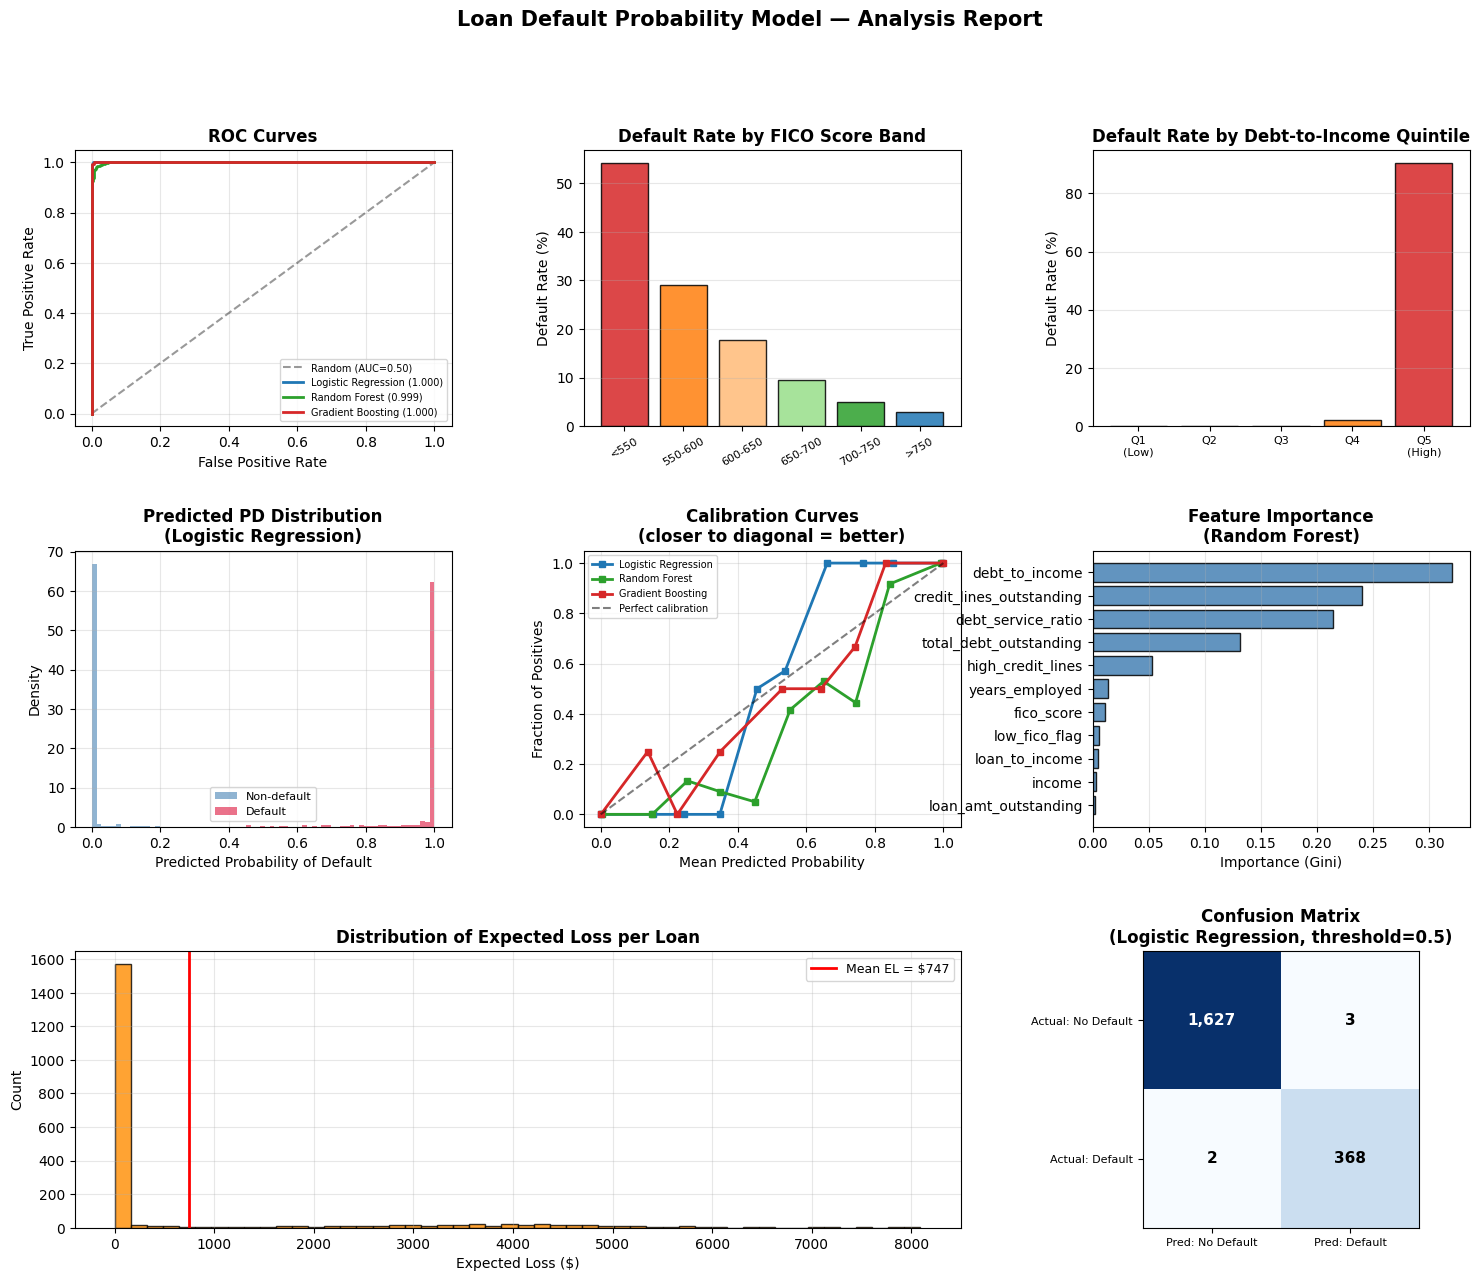


[✓] Chart saved → loan_default_analysis.png


█████████████████████████████████████████████████████████████████
  TEST CASES — EXPECTED LOSS FUNCTION
█████████████████████████████████████████████████████████████████

▶  Test 1: Prime borrower (high FICO, low debt, stable income)
────────────────────────────────────────────────────
  LOAN EXPECTED LOSS REPORT  [Logistic Regression]
────────────────────────────────────────────────────
  Input Features:
    FICO Score:              750
    Annual Income:           $   85,000.00
    Loan Outstanding:        $    5,000.00
    Total Debt:              $    3,000.00
    Credit Lines Open:       1
    Years Employed:          6
  Derived Ratios:
    Debt-to-Income:          0.0353
    Loan-to-Income:          0.0588
────────────────────────────────────────────────────
  Probability of Default:    0.0000  (0.00%)
  Loss Given Default (LGD):  0.90  (recovery = 10%)
  Exposure at Default (EAD): $    5,000.00
  ───────────────────────────────────

In [25]:
# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    # 1. Load
    df = load_data(DATA_PATH)
    explore_data(df)

    # 2. Prepare
    X_train, X_test, y_train, y_test, Xs_train, Xs_test, scaler = prepare_data(df)
    print(f"\n  Train: {len(X_train):,}  |  Test: {len(X_test):,}")

    # 3. Train
    print("\n  Training models...")
    models = train_models(X_train, y_train, Xs_train, Xs_test, X_test, y_test)

    # 4. Evaluate
    results, best_name = evaluate_models(models, X_test, y_test, Xs_test)

    # 5. Feature importance
    print_feature_importance(models, scaler)

    # 6. Plot
    plot_results(models, results, X_test, y_test, Xs_test, df)

    # 7. Build the expected_loss() function
    best_model_info = models[best_name]
    expected_loss   = build_expected_loss_function(best_model_info, scaler, best_name)

    # ══════════════════════════════════════════════════════════════
    # STEP 9: SAMPLE TEST CASES
    # ══════════════════════════════════════════════════════════════

    print("\n\n" + "█" * 65)
    print("  TEST CASES — EXPECTED LOSS FUNCTION")
    print("█" * 65)

    # ── Test 1: Prime borrower — should be LOW RISK ───────────────
    print("\n▶  Test 1: Prime borrower (high FICO, low debt, stable income)")
    r1 = expected_loss(
        credit_lines_outstanding = 1,
        loan_amt_outstanding     = 5000,
        total_debt_outstanding   = 3000,
        income                   = 85000,
        years_employed           = 6,
        fico_score               = 750,
    )

    # ── Test 2: Subprime borrower — should be HIGH RISK ──────────
    print("\n▶  Test 2: Subprime borrower (low FICO, high debt, low income)")
    r2 = expected_loss(
        credit_lines_outstanding = 5,
        loan_amt_outstanding     = 4000,
        total_debt_outstanding   = 22000,
        income                   = 30000,
        years_employed           = 1,
        fico_score               = 540,
    )

    # ── Test 3: Middle-tier — borderline ─────────────────────────
    print("\n▶  Test 3: Mid-tier borrower (average profile)")
    r3 = expected_loss(
        credit_lines_outstanding = 2,
        loan_amt_outstanding     = 3500,
        total_debt_outstanding   = 9000,
        income                   = 60000,
        years_employed           = 4,
        fico_score               = 630,
    )

    # ── Test 4: High income but very high debt ────────────────────
    print("\n▶  Test 4: High income, but heavily indebted (stress test)")
    r4 = expected_loss(
        credit_lines_outstanding = 5,
        loan_amt_outstanding     = 8000,
        total_debt_outstanding   = 35000,
        income                   = 110000,
        years_employed           = 3,
        fico_score               = 580,
    )

    # ── Test 5: Portfolio expected loss (batch mode) ──────────────
    print("\n" + "█" * 65)
    print("  PORTFOLIO EXPECTED LOSS — BATCH CALCULATION")
    print("█" * 65)
    df_full  = engineer_features(df)
    X_all    = df_full[FEATURE_COLS].values
    if best_model_info['needs_scaling']:
        X_all_input = scaler.transform(X_all)
    else:
        X_all_input = X_all

    all_pds   = best_model_info['predict_proba'](X_all_input)
    all_eads  = df_full['loan_amt_outstanding'].values
    all_els   = all_pds * LGD * all_eads

    print(f"\n  Portfolio Summary ({len(df):,} loans):")
    print(f"    Total EAD (book size):         ${all_eads.sum():>15,.2f}")
    print(f"    Total Expected Loss:           ${all_els.sum():>15,.2f}")
    print(f"    Expected Loss Rate:            {all_els.sum()/all_eads.sum()*100:>14.3f}%")
    print(f"    Avg PD across portfolio:       {all_pds.mean()*100:>14.3f}%")
    print(f"    Actual default rate (label):   {df['default'].mean()*100:>14.3f}%")

    risk_tiers = pd.cut(all_pds,
                        bins=[0, 0.05, 0.15, 0.30, 1.0],
                        labels=['Low (<5%)', 'Medium (5-15%)', 'High (15-30%)', 'Very High (>30%)'])
    print(f"\n  Risk tier distribution:")
    tier_counts = pd.Series(risk_tiers).value_counts().sort_index()
    for tier, count in tier_counts.items():
        pct = count/len(df)*100
        bar = '█' * int(pct/2)
